In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [2]:
df = pd.read_csv('../data/processed/pv_weather.csv', parse_dates=['LocalTime'])
df_forecast_benchmark = df[['LocalTime','Power(MW)_DA',	'Power(MW)_HA4']].copy()
df.drop(columns=['ALLSKY_KT','Power(MW)_DA',	'Power(MW)_HA4'],inplace=True)

In [3]:
df.head()

,LocalTime,Power(MW)_ActualEnergy,T2M,WS10M,RH2M,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,PRECTOTCORR
0,2006-01-01 00:00:00,0.0,22.16,4.74,95.38,0.0,0.0,0.00
1,2006-01-01 01:00:00,0.0,22.18,4.78,95.06,0.0,0.0,0.00
2,2006-01-01 02:00:00,0.0,22.22,4.80,94.55,0.0,0.0,0.00
3,2006-01-01 03:00:00,0.0,22.26,4.64,94.14,0.0,0.0,0.00
4,2006-01-01 04:00:00,0.0,22.25,4.31,94.10,0.0,0.0,0.02


In [4]:
df.describe()

,LocalTime,Power(MW)_ActualEnergy,T2M,WS10M,RH2M,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,PRECTOTCORR
count,8760,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,2006-07-02 11:29:59.999999872,44.494698,25.442558,4.698058,75.697200,208.187199,260.462824,2.781305
min,2006-01-01 00:00:00,0.000000,11.120000,0.020000,42.330000,0.000000,0.000000,0.000000
25%,2006-04-02 05:45:00,0.000000,22.960000,2.970000,70.040000,0.000000,0.000000,0.000000
50%,2006-07-02 11:30:00,0.008333,25.790000,4.510000,75.800000,8.360000,10.350000,0.190000
75%,2006-10-01 17:15:00,97.160417,28.500000,6.230000,81.392500,413.677500,557.472500,2.912500
max,2006-12-31 23:00:00,179.025000,31.330000,16.510000,97.470000,1001.330000,1019.080000,92.660000
std,NaN,56.630253,3.495246,2.282108,8.629574,281.079384,333.540065,6.134330


In [5]:
df.set_index('LocalTime', inplace=True)
df = df.asfreq('H')

/tmp/ipykernel_6542/2098490785.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq('H')


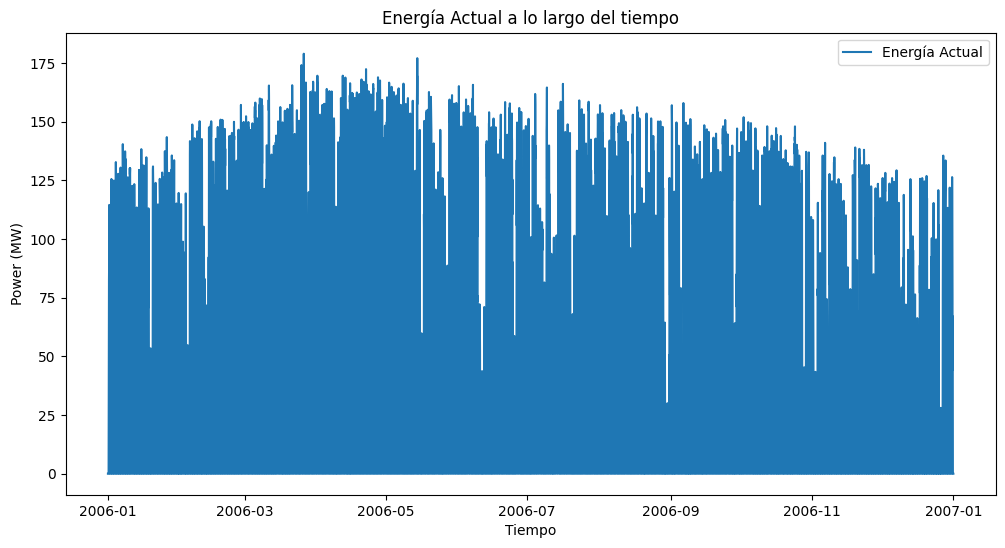

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(df['Power(MW)_ActualEnergy'], label='Energía Actual')
plt.title('Energía Actual a lo largo del tiempo')
plt.xlabel('Tiempo')
plt.ylabel('Power (MW)')
plt.legend()
plt.show()

In [7]:
resultado_adf = adfuller(df['Power(MW)_ActualEnergy'].dropna())
print("ADF Statistic: %f" % resultado_adf[0])
print("p-value: %f" % resultado_adf[1])

ADF Statistic: -10.481742
p-value: 0.000000


In [8]:
modelo = SARIMAX(df['Power(MW)_ActualEnergy'], order=(1, 0, 1), seasonal_order=(1, 1, 1, 24))
modelo_fit = modelo.fit(disp=False)
print(modelo_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:             Power(MW)_ActualEnergy   No. Observations:                 8760
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood              -35747.977
Date:                            Sun, 23 Mar 2025   AIC                          71505.953
Time:                                    03:58:01   BIC                          71541.329
Sample:                                01-01-2006   HQIC                         71518.009
                                     - 12-31-2006                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7100      0.006    110.363      0.000       0.697       0.723
ma.L1          0.1496      0.009   

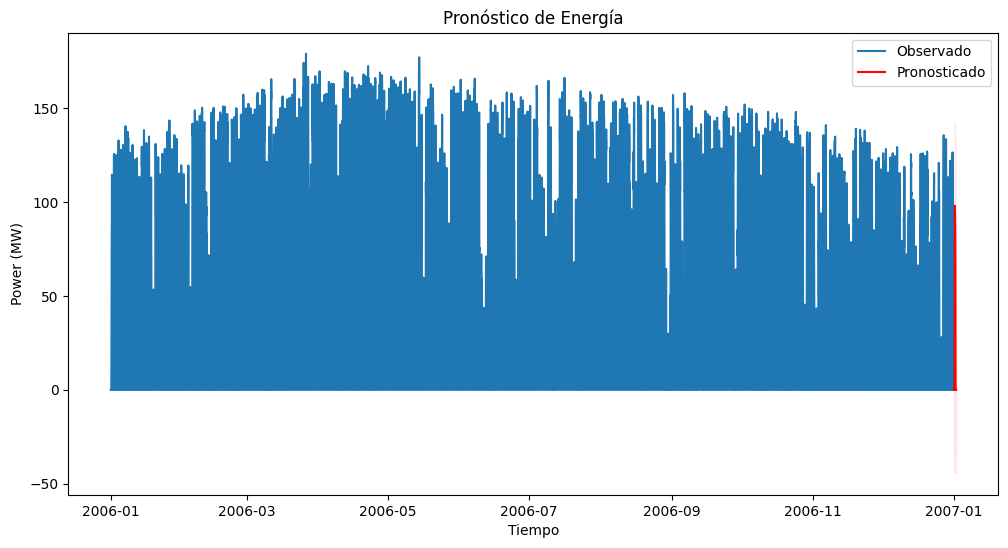

In [9]:
pronostico = modelo_fit.get_forecast(steps=24)
intervalo_conf = pronostico.conf_int()

plt.figure(figsize=(12, 6))
plt.plot(df['Power(MW)_ActualEnergy'], label='Observado')
plt.plot(pronostico.predicted_mean, label='Pronosticado', color='red')
plt.fill_between(intervalo_conf.index,
                 intervalo_conf.iloc[:, 0],
                 intervalo_conf.iloc[:, 1],
                 color='pink', alpha=0.3)
plt.title('Pronóstico de Energía')
plt.xlabel('Tiempo')
plt.ylabel('Power (MW)')
plt.legend()
plt.show()

/tmp/ipykernel_6542/661468208.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq('H')


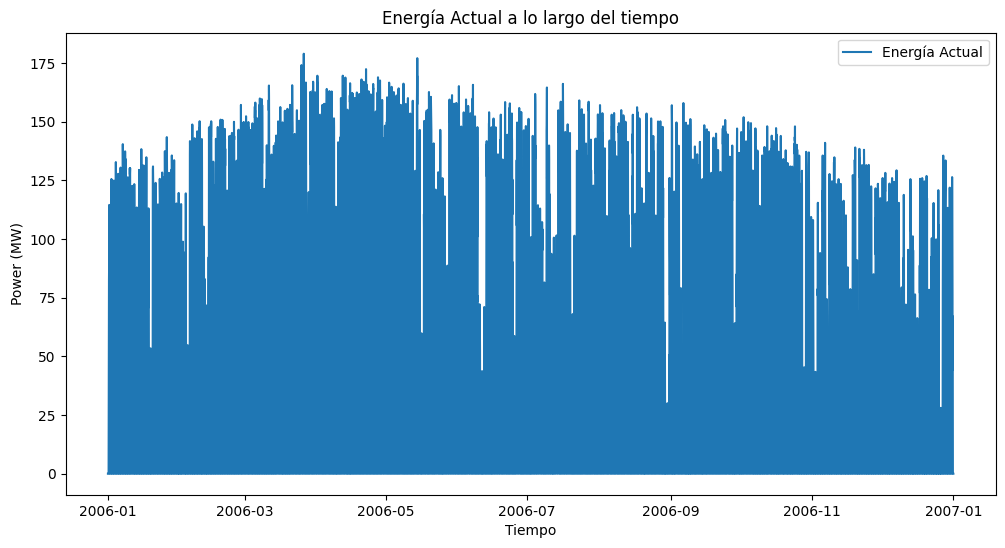

ADF Statistic: -10.481742
p-value: 0.000000
Tamaño del entrenamiento: 7008
Tamaño del test: 1752
                                     SARIMAX Results                                      
Dep. Variable:             Power(MW)_ActualEnergy   No. Observations:                 7008
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 24)   Log Likelihood              -28779.861
Date:                            Sun, 23 Mar 2025   AIC                          57569.723
Time:                                    04:00:17   BIC                          57603.980
Sample:                                01-01-2006   HQIC                         57581.528
                                     - 10-19-2006                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.

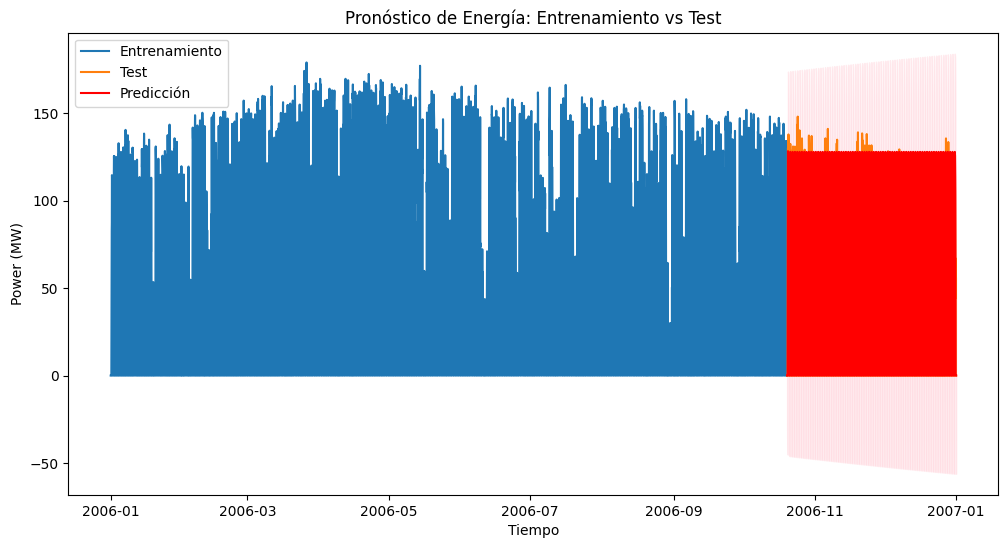

RMSE: 27.52745661143498


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error

# 1. Cargar y preparar los datos
df = pd.read_csv('../data/processed/pv_weather.csv', parse_dates=['LocalTime'])
df.set_index('LocalTime', inplace=True)
df = df.asfreq('H')

# 2. Visualizar la serie original
plt.figure(figsize=(12, 6))
plt.plot(df['Power(MW)_ActualEnergy'], label='Energía Actual')
plt.title('Energía Actual a lo largo del tiempo')
plt.xlabel('Tiempo')
plt.ylabel('Power (MW)')
plt.legend()
plt.show()

# 3. Prueba ADF para confirmar estacionariedad
resultado_adf = adfuller(df['Power(MW)_ActualEnergy'].dropna())
print("ADF Statistic: %f" % resultado_adf[0])
print("p-value: %f" % resultado_adf[1])
# La serie es estacionaria según la prueba ADF.

# 4. Separar los datos en entrenamiento y prueba (80% entrenamiento, 20% prueba)
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]
print("Tamaño del entrenamiento:", len(train))
print("Tamaño del test:", len(test))

# 5. Ajuste del modelo SARIMAX con el conjunto de entrenamiento
# Se utiliza (p,d,q) = (1, 0, 1) para la parte no estacional y (P,D,Q,s) = (1,1,1,24) para capturar la estacionalidad diaria
modelo = SARIMAX(train['Power(MW)_ActualEnergy'], order=(1, 0, 1), seasonal_order=(1, 1, 1, 24))
modelo_fit = modelo.fit(disp=False)
print(modelo_fit.summary())

# 6. Pronóstico para el período de prueba
predicciones = modelo_fit.get_forecast(steps=len(test))
predicted_mean = predicciones.predicted_mean
intervalo_conf = predicciones.conf_int()

# 7. Graficar resultados: entrenamiento, test y predicción
plt.figure(figsize=(12, 6))
plt.plot(train['Power(MW)_ActualEnergy'], label='Entrenamiento')
plt.plot(test['Power(MW)_ActualEnergy'], label='Test')
plt.plot(predicted_mean, label='Predicción', color='red')
plt.fill_between(intervalo_conf.index,
                 intervalo_conf.iloc[:, 0],
                 intervalo_conf.iloc[:, 1],
                 color='pink', alpha=0.3)
plt.title('Pronóstico de Energía: Entrenamiento vs Test')
plt.xlabel('Tiempo')
plt.ylabel('Power (MW)')
plt.legend()
plt.show()

# 8. Cálculo del RMSE para evaluar el modelo
rmse = np.sqrt(mean_squared_error(test['Power(MW)_ActualEnergy'], predicted_mean))
print("RMSE:", rmse)
